### Instalación de librerías

In [159]:
from IPython import display
%pip install tensorflow
%pip install keras
%pip install matplotlib
%pip install scipy
display.clear_output()

### Imports

In [160]:
import json
import keras
import numpy as np

from pathlib import Path
from typing import Optional
from keras.models import Model
import matplotlib.pyplot as plt
from scipy.special import softmax
from keras.models import Sequential
from keras.callbacks import Callback
from typing import Tuple, Dict, List
from tensorflow.keras.utils import pad_sequences
from keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

### Desarrollo del desafío

#### Preprocesamiento del corpus

El primer paso consiste en preparar el texto del corpus para que pueda ser utilizado por el modelo de lenguaje. Este bloque se encarga de:

- Cargar el contenido completo del primer libro de Harry Potter.
- Normalizar el texto eliminando inconsistencias (como mayúsculas, espacios dobles o saltos de línea).
- Extraer el vocabulario de caracteres presentes en el corpus.
- Generar los diccionarios necesarios para convertir texto en índices numéricos y viceversa.

Estas transformaciones permiten pasar de un archivo .txt en lenguaje natural a una representación numérica estructurada, lista para ser tokenizada y utilizada en el entrenamiento del modelo.

In [161]:
def load_text_file(file_path: str) -> str:
    """Load the content of a text file.

    :param file_path: Path to the text file
    :return: Content of the file as a single string
    """
    with open(file_path, 'r', encoding='utf-8') as file:
        return file.read()


def preprocess_text(text: str) -> str:
    """Preprocess the text by converting to lowercase and removing newline characters.

    :param text: Raw text
    :return: Cleaned and normalized text
    """
    text = text.lower().replace('\n', ' ')
    text = text.replace('  ', ' ')
    return text


def create_char_mappings(text: str) -> Tuple[Dict[str, int], Dict[int, str]]:
    """Create character-to-index and index-to-character mappings.

    :param text: Preprocessed text
    :return: Tuple containing char2idx and idx2char dictionaries
    """
    unique_chars = sorted(set(text))
    char2idx = {char: idx for idx, char in enumerate(unique_chars)}
    idx2char = {idx: char for idx, char in enumerate(unique_chars)}
    return char2idx, idx2char


#### Tokenización del texto

Una vez preprocesado el corpus, el siguiente paso consiste en convertir el texto en una secuencia de enteros que representen cada carácter. Esta transformación permite trabajar con el texto de forma numérica, que es el formato que requieren los modelos de redes neuronales.

La tokenización se realiza a nivel de caracteres, utilizando un diccionario que asigna a cada carácter único un índice entero. El resultado es una lista de enteros que representa el texto completo del corpus de forma continua.

Esta secuencia tokenizada será la base para construir los ejemplos de entrenamiento y validación.

In [162]:
def tokenize_text(text: str, char2idx: Dict[str, int]) -> List[int]:
    """Tokenize the text at character level using a provided character-to-index mapping.

    :param text: Preprocessed input text (lowercased, no line breaks)
    :param char2idx: Dictionary mapping characters to integer indices
    :return: List of integer tokens representing the text
    """
    return [char2idx[ch] for ch in text if ch in char2idx]

#### Segmentación del corpus y construcción de datos de entrenamiento y validación

A partir del texto tokenizado, se generan las secuencias de entrenamiento y validación que el modelo utilizará durante el aprendizaje. Este proceso implica recorrer el texto en forma continua con una ventana deslizante de longitud fija (max_context_size), lo que permite extraer múltiples subsecuencias superpuestas.

El corpus se divide en dos subconjuntos:
- El conjunto de entrenamiento corresponde a la mayor parte del texto inicial.
- El conjunto de validación se extrae del final del corpus y permite evaluar la capacidad del modelo para generalizar.

Cada una de estas subsecuencias se transforma en un par entrada–objetivo desplazado carácter a carácter:
- La entrada X contiene todos los caracteres de la secuencia menos el último.
- El objetivo y contiene todos los caracteres excepto el primero, desplazados una posición hacia la izquierda.

Este esquema implementa un enfoque *many-to-many* a nivel temporal, en el cual el modelo produce una predicción por cada carácter de entrada, permitiendo una propagación más rica de gradientes y un entrenamiento más efectivo.

In [163]:
def split_tokenized_text(
    tokenized_text: List[int], 
    max_context_size: int, 
    p_val: float = 0.1
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Split tokenized text into training and validation datasets with aligned input-output sequences.

    :param tokenized_text: List of character-level tokens (as integers)
    :param max_context_size: Total length of each sequence (including input and target)
    :param p_val: Proportion of the text to use for validation
    :return: Tuple containing X_train, y_train, X_val, y_val
    """
    num_val = int(np.ceil(len(tokenized_text) * p_val / max_context_size))
    train_text = tokenized_text[:-num_val * max_context_size]
    val_text = tokenized_text[-num_val * max_context_size:]

    train_sequences = [
        train_text[i:i + max_context_size]
        for i in range(len(train_text) - max_context_size + 1)
    ]
    
    val_sequences = [
        val_text[i:i + max_context_size]
        for i in range(len(val_text) - max_context_size + 1)
    ]

    X_train = np.array(train_sequences[:-1])
    y_train = np.array(train_sequences[1:])
    X_val = np.array(val_sequences[:-1])
    y_val = np.array(val_sequences[1:])

    return X_train, y_train, X_val, y_val


#### Ejecución del pipeline de preprocesamiento y segmentación


En este bloque se integran todas las funciones previamente definidas para preparar los datos que serán utilizados por el modelo. El proceso completo sigue los siguientes pasos:

1. Se carga el contenido del archivo de texto que contiene el corpus.
2. Se aplica el preprocesamiento para normalizar el texto.
3. Se construyen los diccionarios de mapeo entre caracteres e índices.
4. Se tokeniza el texto completo a nivel de caracteres, convirtiéndolo en una secuencia de enteros.
5. Se define el tamaño del contexto (longitud fija de las secuencias de entrada).
6. Se generan las secuencias de entrenamiento y validación a partir del texto tokenizado, dividiéndolo en ventanas adecuadas para alimentar al modelo.

Como resultado, se obtiene un conjunto de datos en formato numérico (X, y) listo para ser utilizado durante el entrenamiento, junto con las secuencias de validación necesarias para evaluar el rendimiento del modelo.

In [164]:
BOOK_DIR = Path('./hp/01 Harry Potter and the Sorcerers Stone.txt')
corpus_text = preprocess_text(load_text_file(BOOK_DIR))
char2idx, idx2char = create_char_mappings(corpus_text)
vocab_size = len(char2idx)
tokenized_text = tokenize_text(corpus_text, char2idx)
max_context_size = 100
X_train, y_train, X_val, y_val = split_tokenized_text(tokenized_text, max_context_size)

In [165]:
print(f'Muestra de texto: {corpus_text[:101]}')
print(f'Número de caracteres únicos: {vocab_size}')
print(f'Longitud del texto tokenizado: {len(tokenized_text)}')
print(f'Longitud de X_train: {X_train.shape}, Longitud de y_train: {y_train.shape}')
print(f'Número de secuencias de validación: {len(X_val)}')

Muestra de texto: mr. and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal
Número de caracteres únicos: 55
Longitud del texto tokenizado: 436199
Longitud de X_train: (392399, 100), Longitud de y_train: (392399, 100)
Número de secuencias de validación: 43600


In [166]:
print(f'Sequencias de entrenamiento de largo {len(X_train[0])}: ', end='\n\n')
for i in range(4):
    x_seq = ''.join([idx2char[idx] for idx in X_train[i]])
    y_seq = ''.join([idx2char[idx] for idx in y_train[i]])
    print(f'X[{i}]: {x_seq}')
    print(f'y[{i}]: {y_seq}')
    print('-' * 40)

Sequencias de entrenamiento de largo 100: 

X[0]: mr. and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly norma
y[0]: r. and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal
----------------------------------------
X[1]: r. and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal
y[1]: . and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal,
----------------------------------------
X[2]: . and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal,
y[2]:  and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal, 
----------------------------------------
X[3]:  and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal, 
y[3]: and mrs. dursley, of number four, privet drive, were proud to say that they we

#### Funciones y clases de uso común

Se definieron dos funciones con el objetivo de automatizar y reutilizar el proceso de entrenamiento y evaluación del modelo de lenguaje, permitiendo aplicar exactamente el mismo flujo para distintas arquitecturas (SimpleRNN, LSTM y GRU), manteniendo la trazabilidad y comparabilidad de resultados.

##### train_or_load_model

Esta función encapsula la lógica para:
- Cargar pesos previamente entrenados, si existen en disco.
- Si no existen, entrenar el modelo con los datos provistos (X_train, y_train, X_val, y_val).
- Guardar los pesos del modelo y el historial de entrenamiento (evolución de la perplejidad) en un archivo definido por el usuario.
- Retornar un diccionario con el historial de entrenamiento, ya sea cargado desde archivo o generado durante el fit.

Esto permite evitar entrenamientos innecesarios y mantener una estructura clara para múltiples experimentos.

In [167]:
def train_or_load_model(
    model: Model,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    y_val: np.ndarray,
    weights_file: str,
    history_file: str,
    callback: Optional[Callback] = None,
    epochs: int = 20,
    batch_size: int = 256
) -> dict:
    """
    Loads model weights if available; otherwise trains the model, saves weights and history.

    :param model: Compiled Keras model
    :param X_train: Training input sequences
    :param y_train: Training targets
    :param X_val: Validation input sequences
    :param y_val: Validation targets
    :param weights_file: Path to save/load model weights
    :param history_file: Path to save/load training history
    :param callback: Optional Keras callback
    :param epochs: Number of training epochs
    :param batch_size: Batch size
    :return: Training history dictionary
    """
    weights_path = Path(weights_file)
    if weights_path.exists():
        model.load_weights(str(weights_path))
        print(f'Pesos cargados desde "{weights_file}"')
        hist = None
    else:
        callbacks = [callback] if callback else []
        hist = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            callbacks=callbacks,
            batch_size=batch_size
        )
        model.save_weights(str(weights_path))
        with open(history_file, 'w') as f:
            json.dump(hist.history, f)

    history_path = Path(history_file)
    if history_path.exists():
        print(f'Cargando historial de entrenamiento desde {history_path}')
        with open(history_path, 'r') as f:
            return json.load(f)
    elif hist:
        return hist.history
    else:
        return {}

##### plot_perplexity

Esta función recibe el historial de entrenamiento devuelto por train_or_load_model y genera un gráfico con la evolución de la perplejidad tanto en entrenamiento como en validación. Permite visualizar de forma rápida la convergencia del modelo y detectar potenciales problemas como sobreajuste.

In [168]:
def plot_perplexity(history: dict):
    """
    Plots the evolution of training and validation perplexity.

    :param history: Dictionary containing 'perplexity' and 'val_perplexity' lists
    """
    train_perplexity = history.get('perplexity', [])
    val_perplexity = history.get('val_perplexity', [])

    plt.figure(figsize=(8, 5))
    plt.plot(train_perplexity, label='Train Perplexity')
    plt.plot(val_perplexity, label='Validation Perplexity')
    plt.xlabel('Epoch')
    plt.ylabel('Perplexity')
    plt.title('Evolución de la Perplejidad')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

##### Uso con distintas arquitecturas

La idea es definir modelos con distintas celdas recurrentes (por ejemplo, SimpleRNN, LSTM, GRU), compilar cada uno, y luego llamar:

```python
history = train_or_load_model(
    model=my_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val,
    weights_file='model_lstm.weights.h5',
    history_file='model_lstm_history.json',
    callback=PerplexityCallback(),
    epochs=20
)
plot_perplexity(history)
```

Cambiando únicamente el modelo y los nombres de los archivos de pesos e historial, se puede reutilizar el mismo flujo completo, lo que facilita las comparaciones cuantitativas entre modelos entrenados bajo condiciones controladas.

##### Custom callback calculando perplejidad

Para evaluar el rendimiento del modelo durante el entrenamiento, se utiliza un callback personalizado que calcula la perplejidad.

El callback calcula esta métrica exponenciando el valor de la pérdida (loss y val_loss) al final de cada época. Esto proporciona una medida más interpretable que el valor bruto de la función de pérdida, y permite detectar fácilmente sobreajuste o falta de aprendizaje.

In [169]:
class PerplexityCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()

    def on_epoch_end(self, epoch, logs=None):
        # Calculate and log training perplexity
        train_loss = logs.get('loss')
        if train_loss is not None:
            train_perplexity = np.exp(train_loss)
            print(f'\nTraining Perplexity: {train_perplexity:.4f}')
            logs['perplexity'] = train_perplexity

        # Calculate and log validation perplexity if validation data is provided
        val_loss = logs.get('val_loss')
        if val_loss is not None:
            val_perplexity = np.exp(val_loss)
            print(f'Validation Perplexity: {val_perplexity:.4f}')
            logs['val_perplexity'] = val_perplexity

##### generate_text

Se utiliza una función auxiliar generate_text() para probar el modelo generando texto carácter a carácter. A partir de una secuencia inicial (prompt), la función convierte los caracteres en índices, los pasa por el modelo y predice el siguiente carácter.

Esta predicción se incorpora al contexto de entrada y el proceso se repite de forma autoregresiva, generando una secuencia de longitud deseada. La función emplea una estrategia de decodificación codiciosa (greedy decoding), donde en cada paso se elige el carácter con mayor probabilidad.

Si bien en el notebook de la clase se utiliza padding explícito (pad_sequences) para completar las secuencias de entrada hasta alcanzar la longitud máxima (max_context_size), en este caso se opta por no aplicar padding durante la generación de texto.

Esto se debe a que el modelo, una vez entrenado, es capaz de recibir secuencias de entrada de cualquier longitud durante la inferencia, siempre y cuando mantengan la estructura esperada (una matriz 2D de índices de caracteres). No es necesario forzar una longitud fija si el objetivo es generar texto carácter a carácter, donde el contexto se va actualizando dinámicamente.

Además, aplicar padding (especialmente con ceros al principio) introduciría información artificial y poco útil al modelo, lo que podría interferir con la predicción del siguiente carácter. Esto es particularmente importante en tareas de generación autoregresiva, donde la calidad del contexto reciente es crítica.

Por esta razón, en lugar de paddear las secuencias, se utiliza una ventana deslizante que mantiene como contexto únicamente los últimos caracteres relevantes generados hasta ese momento.

In [170]:
def generate_text(
    model,
    start_string: str,
    char2idx: dict,
    idx2char: dict,
    length: int = 200,
    temperature: float = 0.0,
    max_context_size: int = 100  # Debe coincidir con lo usado durante entrenamiento
) -> str:
    """
    Generate text using greedy decoding or sampling with temperature.

    :param model: Trained Keras model
    :param start_string: Prompt to start generation
    :param char2idx: Character to index dictionary
    :param idx2char: Index to character dictionary
    :param length: Number of characters to generate
    :param temperature: Sampling temperature. 0 = greedy, > 0 = probabilistic sampling
    :param max_context_size: Length of context (input sequence length used in training)
    :return: Generated text
    """
    input_eval = [char2idx[c] for c in start_string.lower() if c in char2idx]
    input_eval = pad_sequences([input_eval], maxlen=max_context_size - 1, padding='pre')
    
    generated = list(start_string)

    for _ in range(length):
        predictions = model.predict(input_eval, verbose=0)
        last_time_step = predictions[:, -1, :].flatten()

        if temperature == 0.0:
            next_index = np.argmax(last_time_step)
        else:
            logits = last_time_step / temperature
            probabilities = softmax(logits)
            next_index = np.random.choice(len(probabilities), p=probabilities)

        next_char = idx2char[next_index]
        generated.append(next_char)

        # Update input sequence with sliding window
        next_input = np.append(input_eval[0], next_index)[-input_eval.shape[1]:]
        input_eval = np.expand_dims(next_input, 0)

    return ''.join(generated)


#### SimpleRNN

Para este modelo de lenguaje se utiliza una capa de Embedding como primer paso en lugar de una codificación one-hot explícita. Esta decisión se basa en que, aunque se trabaja a nivel de caracteres, los vectores densos aprendibles permiten capturar patrones de uso y relaciones estadísticas entre símbolos, mejorando la eficiencia y el rendimiento del modelo. Además, este enfoque reduce el consumo de memoria al evitar representaciones dispersas y escala mejor en caso de ampliar el vocabulario.

El modelo completo incluye:
- Una capa Embedding que transforma cada índice de carácter en un vector denso de dimensión fija.
- Una capa recurrente SimpleRNN que procesa la secuencia temporal de vectores.
- Una capa Dense con activación softmax que predice la probabilidad del próximo carácter en la secuencia.

In [171]:
model_simplernn = Sequential(name='SimpleRNN_embedding')
model_simplernn.add(Embedding(input_dim=vocab_size, output_dim=32))
model_simplernn.add(SimpleRNN(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
model_simplernn.add(Dense(vocab_size, activation='softmax'))
model_simplernn.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_simplernn.build(input_shape=(None, max_context_size))
model_simplernn.summary()

Model: "SimpleRNN_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 100, 32)        │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 100, 200)       │        46,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 100, 55)        │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,415 (232.09 KB)

 Trainable params: 59,415 (232.09 KB)

 Non-trainable params: 0 (0.00 B)

Pesos cargados desde "hp_simplernn_char.weights.h5"
Cargando historial de entrenamiento desde hp_simplernn_char_training_history.json


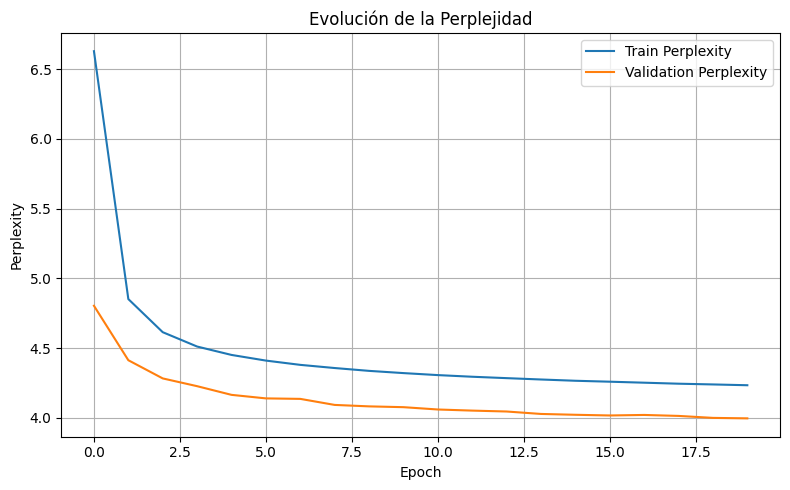

In [172]:
weights_path = 'hp_simplernn_char.weights.h5'
history_path = 'hp_simplernn_char_training_history.json'

history = train_or_load_model(
    model_simplernn,
    X_train, y_train,
    X_val, y_val,
    weights_file=weights_path,
    history_file=history_path,
    callback=PerplexityCallback(),
    epochs=20,
    batch_size=256,
)

plot_perplexity(history)

El gráfico muestra una disminución progresiva de la perplejidad tanto en los datos de entrenamiento como de validación, lo cual indica que el modelo fue mejorando su capacidad para predecir correctamente el carácter siguiente en una secuencia.

La perplejidad de validación se mantiene sistemáticamente por debajo de la de entrenamiento, lo que sugiere que el modelo no está sobreajustando y generaliza de manera razonable. Si bien las curvas comienzan con un descenso abrupto, luego se estabilizan y tienden a converger lentamente, lo cual es esperable en entrenamientos con redes recurrentes sobre corpus limitados como el que se está usando.

Este comportamiento indica que el modelo está capturando patrones sintácticos del lenguaje, aunque aún puede mejorarse con una arquitectura más potente o un corpus más amplio.

In [173]:
print(generate_text(model_simplernn, start_string='harry', char2idx=char2idx, idx2char=idx2char, length=100))

harry started the stone started the stone started the stone started the stone started the stone started t


Este resultado refleja que el modelo ha aprendido cierta estructura gramatical básica y es capaz de generar secuencias coherentes desde el punto de vista sintáctico. Sin embargo, la generación es altamente repetitiva y carece de diversidad, lo que sugiere que el modelo tiende a reforzar patrones de alta probabilidad local sin variación.

Este comportamiento es común en redes SimpleRNN, que presentan limitaciones para capturar dependencias largas y diversidad contextual. En las siguientes etapas se reemplazará esta arquitectura por una LSTM, con el objetivo de mejorar la calidad del texto generado.

#### LSTM

Para esta variante, se reemplaza la capa recurrente SimpleRNN por una capa LSTM, una arquitectura diseñada específicamente para superar las limitaciones de las RNN simples al capturar dependencias de largo plazo en secuencias.

Las LSTM incorporan mecanismos de memoria controlados por compuertas que permiten al modelo decidir qué información mantener, olvidar o actualizar en cada paso temporal. Esto las hace particularmente adecuadas para tareas de modelado de lenguaje, donde el contexto previo puede ser crucial para predecir correctamente el siguiente carácter o palabra.

Arquitectura propuesta:

- Una capa Embedding, igual que en el modelo anterior, para representar caracteres como vectores densos.
- Una capa LSTM con 200 unidades, que procesa la secuencia y mantiene un estado interno a lo largo del tiempo.
- Una capa Dense con activación softmax para predecir la distribución de probabilidad sobre el próximo carácter.

In [174]:
model_lstm = Sequential(name='LSTM_embedding')
model_lstm.add(Embedding(input_dim=vocab_size, output_dim=32))
model_lstm.add(LSTM(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
model_lstm.add(Dense(vocab_size, activation='softmax'))
model_lstm.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_lstm.build(input_shape=(None, max_context_size))
model_lstm.summary()

Model: "LSTM_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ (None, 100, 32)        │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 200)       │       186,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 100, 55)        │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 199,215 (778.18 KB)

 Trainable params: 199,215 (778.18 KB)

 Non-trainable params: 0 (0.00 B)

Pesos cargados desde "hp_lstm_char.weights.h5"
Cargando historial de entrenamiento desde hp_lstm_char_training_history.json


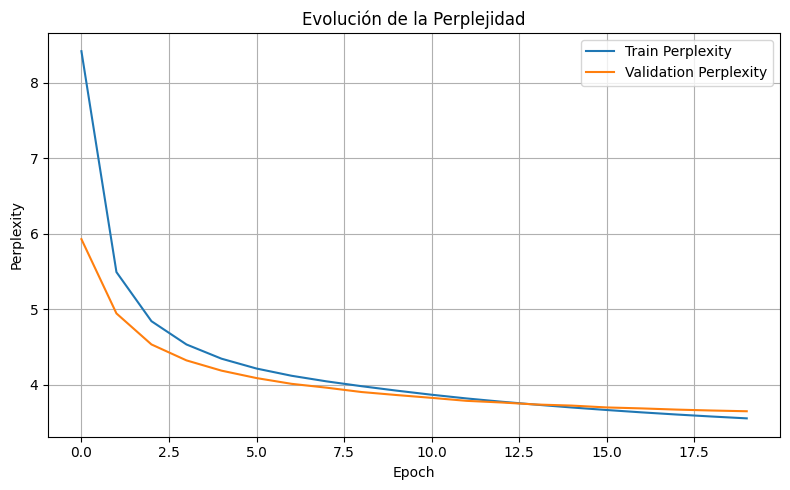

In [175]:
weights_path = 'hp_lstm_char.weights.h5'
history_path = 'hp_lstm_char_training_history.json'

history = train_or_load_model(
    model_lstm,
    X_train, y_train,
    X_val, y_val,
    weights_file=weights_path,
    history_file=history_path,
    callback=PerplexityCallback(),
    epochs=20,
    batch_size=256,
)

plot_perplexity(history)

El gráfico muestra una disminución progresiva y sostenida de la perplejidad en ambas curvas, con un descenso inicial pronunciado seguido de una convergencia más suave. Este comportamiento es característico de un modelo que está aprendiendo progresivamente los patrones del corpus de entrenamiento y mejorando su capacidad de predicción.

En comparación con el modelo SimpleRNN, el LSTM alcanza valores de perplejidad menores tanto en entrenamiento como en validación, lo que confirma su superioridad para capturar dependencias temporales más complejas. Además, la curva de perplejidad en LSTM es más suave y estable, lo que evidencia un proceso de entrenamiento más controlado y menos propenso a oscilaciones.

Estos resultados son coherentes con las ventajas esperadas de la arquitectura LSTM, que gracias a sus compuertas internas logra conservar y olvidar información de manera dinámica, adaptándose mejor a la estructura del lenguaje en comparación con redes recurrentes más simples.


In [176]:
print(generate_text(model_lstm, start_string='harry', char2idx=char2idx, idx2char=idx2char, length=100))

harry potter and the stone started to the stone of the stone of the stone of the stone of the stone of th


En comparación con el modelo basado en SimpleRNN, se observa una mejora en la coherencia y estructura sintáctica. La frase generada contiene nombres propios, conectores y construcciones que reflejan patrones reales del corpus, como "harry potter and the stone", lo cual sugiere que el modelo ha aprendido relaciones estadísticas plausibles entre secuencias de caracteres.

Sin embargo, también se aprecian limitaciones típicas del enfoque basado en greedy decoding: la generación tiende a converger hacia repeticiones o secuencias de alta probabilidad local, lo que reduce la diversidad del texto producido. Por ejemplo, el modelo cae en una construcción parcialmente repetitiva con la palabra "stone", indicando que aún no logra romper con patrones dominantes del corpus.

Este comportamiento es esperable teniendo en cuenta que el corpus es relativamente acotado (un único libro) y que la estrategia de decodificación empleada selecciona siempre el carácter más probable, sin introducir variación.

#### GRU

En esta variante, se utiliza una celda GRU (Gated Recurrent Unit) como alternativa a las arquitecturas SimpleRNN y LSTM. Las GRU fueron diseñadas como una simplificación de las LSTM, manteniendo mecanismos de compuertas que permiten controlar el flujo de información en la secuencia temporal, pero con una estructura interna más liviana y eficiente computacionalmente.

Las GRU combinan las funciones de memoria y olvido en menos parámetros que una LSTM, lo que las hace una opción atractiva cuando se busca un balance entre capacidad de modelado y eficiencia. Conservan la habilidad de capturar dependencias de largo plazo sin la complejidad completa de las LSTM.

Arquitectura propuesta:

- Una capa Embedding, como en los modelos anteriores, que transforma cada índice de carácter en un vector denso de dimensión fija.
- Una capa GRU con 200 unidades, que procesa la secuencia manteniendo un estado oculto recurrente con mecanismos de compuerta.
- Una capa Dense con activación softmax que predice la probabilidad del próximo carácter en la secuencia.

In [177]:
model_gru = Sequential(name='GRU_embedding')
model_gru.add(Embedding(input_dim=vocab_size, output_dim=32))
model_gru.add(GRU(200, return_sequences=True, dropout=0.1, recurrent_dropout=0.1))
model_gru.add(Dense(vocab_size, activation='softmax'))
model_gru.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop')
model_gru.build(input_shape=(None, max_context_size))
model_gru.summary()

Model: "GRU_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 100, 32)        │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 100, 200)       │       140,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 100, 55)        │        11,055 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,215 (598.50 KB)

 Trainable params: 153,215 (598.50 KB)

 Non-trainable params: 0 (0.00 B)

Pesos cargados desde "hp_gru_char.weights.h5"
Cargando historial de entrenamiento desde hp_gru_char_training_history.json


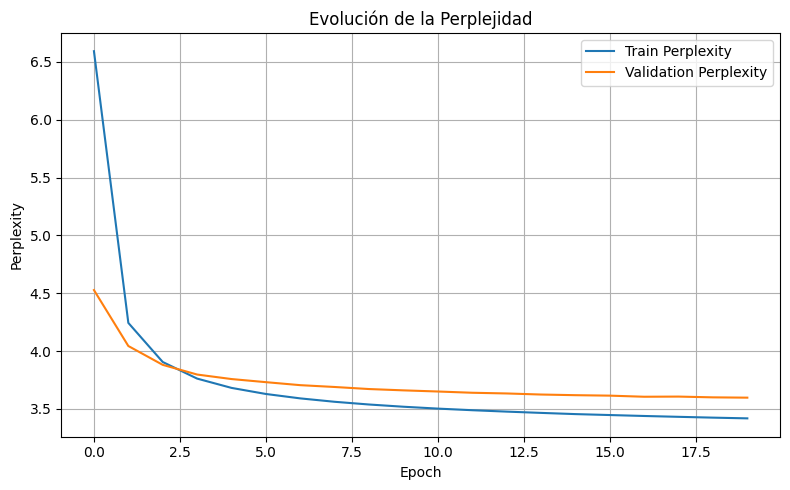

In [178]:
# Punto 3 - Entrenamiento y visualización de la perplejidad del modelo GRU

weights_path = 'hp_gru_char.weights.h5'
history_path = 'hp_gru_char_training_history.json'

history = train_or_load_model(
    model_gru,
    X_train, y_train,
    X_val, y_val,
    weights_file=weights_path,
    history_file=history_path,
    callback=PerplexityCallback(),
    epochs=20,
    batch_size=256,
)

plot_perplexity(history)


El gráfico muestra una reducción consistente de la perplejidad tanto en entrenamiento como en validación, con una rápida caída inicial seguida de una progresión más gradual hacia valores convergentes. Esto confirma que el modelo GRU ha aprendido patrones del lenguaje de forma efectiva.

Un aspecto interesante es que la curva de validación se mantiene ligeramente por encima de la de entrenamiento, lo cual es habitual cuando el conjunto de validación es más complejo o diverso. Este contraste moderado puede ser resultado natural de una regularización efectiva (como el dropout) y no sugiere sobreajuste, especialmente dado que ambas curvas continúan descendiendo de forma paralela.

Comparado con SimpleRNN y LSTM, el GRU logra alcanzar los valores más bajos de perplejidad en ambas etapas, lo que indica una mejor generalización y capacidad de predicción. Además, la curva es más suave, lo que refleja un entrenamiento más estable y menos propenso a oscilaciones.

Estas observaciones confirman que el modelo GRU, bajo esta configuración, presenta el mejor rendimiento del experimento: logra combinar eficiencia (menos parámetros y entrenamiento más rápido), robustez en la validación y menor perplejidad absoluta, lo que lo reafirma como la mejor opción para continuar con estrategias de generación más avanzadas.

In [179]:
print(generate_text(model_gru, start_string='harry', char2idx=char2idx, idx2char=idx2char, length=100))

harry potter, i’m not to see you think you can’t you think i’m going to see you think you can’t you think


Este resultado representa una mejora clara respecto a los modelos anteriores. A diferencia de SimpleRNN, que generaba secuencias extremadamente repetitivas y del modelo LSTM, que también caía en patrones cíclicos, el modelo GRU logra producir una secuencia más fluida y variada.

Si bien el resultado aún carece de una estructura semántica completamente sólida (la frase pierde sentido hacia el final), la generación muestra varios aspectos positivos:

- No hay repeticiones claras ni bucles locales, lo cual es un avance importante.
- Se utilizan conectores y construcciones comunes del inglés ("i’m not", "to see", "you think"), lo que sugiere que el modelo ha aprendido patrones sintácticos más profundos.
- La diversidad léxica es mayor, con una combinación de verbos, pronombres y contracciones que no estaban presentes en las generaciones previas.

Este comportamiento más rico y menos predecible es una señal de que el modelo GRU captura mejor las dinámicas del lenguaje del corpus, y no queda atrapado en los máximos locales de probabilidad que limitaban a los otros modelos. Aun así, el resultado no alcanza un nivel completamente natural o coherente, lo que abre el camino para estrategias de generación más sofisticadas como sampling con temperatura ajustada o beam search estocástico.

#### Selección de modelo y generación de texto con temperatura y beam search

Hasta este punto del trabajo, las secuencias de texto fueron generadas utilizando una estrategia de greedy search, que consiste en seleccionar en cada paso el carácter con mayor probabilidad según la distribución predicha por el modelo. Si bien esta estrategia es simple y eficiente, tiende a producir resultados repetitivos y poco diversos.

Se compararon tres arquitecturas diferentes de redes recurrentes: SimpleRNN, LSTM y GRU, todas con 200 unidades, entrenadas durante 20 épocas sobre el mismo corpus de texto. A través de una inspección visual de las secuencias generadas y del análisis de la evolución de la perplejidad, se observó que el modelo basado en GRU logró los mejores resultados.

El modelo GRU no solo produjo salidas más coherentes y variadas, sino que además presentó ventajas adicionales:
- Menor cantidad de parámetros (~153 mil vs. ~199 mil en LSTM).
- Menor tiempo de entrenamiento por época, gracias a su arquitectura más simple que evita el uso de múltiples compuertas internas como en las LSTM.
- Perplejidad de validación más baja al final del entrenamiento, lo que indica una mejor capacidad de generalización.

Dado esto, se selecciona la arquitectura GRU como la más adecuada para continuar con la experimentación. En esta etapa, se utilizará dicho modelo para analizar secuencias generadas utilizando otras estrategias más sofisticadas de decodificación:
- Greedy search (ya evaluada),
- Sampling con temperatura, y
- Beam search, tanto determinístico como estocástico.

Estas variantes permitirán observar cómo impactan diferentes enfoques de generación en la diversidad y coherencia de las secuencias producidas.

In [180]:
def encode(text, char2idx, max_length=max_context_size):
    encoded = [char2idx[ch] for ch in text]
    encoded = pad_sequences([encoded], maxlen=max_length, padding='pre')
    return encoded


def decode(seq, idx2char):
    return ''.join([idx2char[ch] for ch in seq])


def select_candidates(pred,num_beams,vocab_size,history_probs,history_tokens,temp,mode):
    # Colectar todas las probabilidades para la siguiente búsqueda
    pred_large = []
    for idx,pp in enumerate(pred):
        pred_large.extend(np.log(pp+1E-10)+history_probs[idx])
    pred_large = np.array(pred_large)
    # Criterio de selección
    if mode == 'det':
        idx_select = np.argsort(pred_large)[::-1][:num_beams] # beam search determinista
    elif mode == 'sto':
        idx_select = np.random.choice(np.arange(pred_large.shape[0]), num_beams, p=softmax(pred_large/temp)) # beam search con muestreo aleatorio
    else:
        raise ValueError(f'Wrong selection mode. {mode} was given. det and sto are supported.')

    # Traducir a índices de token en el vocabulario
    new_history_tokens = np.concatenate(
        (np.array(history_tokens)[idx_select//vocab_size], np.array([idx_select%vocab_size]).T),
        axis=1
    )
    # Devolver el producto de las probabilidades (log) y la secuencia de tokens seleccionados
    return pred_large[idx_select.astype(int)], new_history_tokens.astype(int)


def beam_search(model, num_beams, num_chars, input, char2idx, temp=1, mode='det'):
    # First iteration
    # Encode
    encoded = encode(input, char2idx, max_length=max_context_size)
    # First prediction
    y_hat = model.predict(encoded,verbose=0)[0,-1,:]
    # Get vocabulary size
    vocab_size = y_hat.shape[0]
    # Initialize history
    history_probs = [0]*num_beams
    history_tokens = [encoded[0]]*num_beams
    # Select num_beams candidates
    history_probs, history_tokens = select_candidates(
        [y_hat],
        num_beams,
        vocab_size,
        history_probs,
        history_tokens,
        temp,
        mode
    )
    # Beam search loop
    for i in range(num_chars-1):
        preds = []
        for hist in history_tokens:
            # actualizar secuencia de tokens
            input_update = np.array([hist[i+1:]]).copy()
            # predicción
            y_hat = model.predict(input_update,verbose=0)[0,-1,:]
            preds.append(y_hat)
        history_probs, history_tokens = select_candidates(
            preds,
            num_beams,
            vocab_size,
            history_probs,
            history_tokens,
            temp,
            mode
        )
    return history_tokens[:,-(len(input)+num_chars):]

In [181]:
def beam_generate_text(
    model,
    start_string: str,
    char2idx: dict,
    idx2char: dict,
    length: int = 200,
    num_beams: int = 3,
    temperature: float = 1.0,
    mode: str = 'det'  # 'det' o 'sto'
) -> str:
    """
    Generate text using Beam Search.

    :param model: Trained Keras model
    :param start_string: Prompt
    :param char2idx: Character to index mapping
    :param idx2char: Index to character mapping
    :param length: Number of characters to generate
    :param num_beams: Beam width
    :param temperature: Sampling temperature (only used in stochastic mode)
    :param mode: 'det' for deterministic, 'sto' for stochastic
    :return: Generated sequence
    """
    result_tokens = beam_search(
        model=model,
        num_beams=num_beams,
        num_chars=length,
        input=start_string.lower(),
        char2idx=char2idx,
        temp=temperature,
        mode=mode
    )
    return decode(result_tokens[0], idx2char)

En esta sección se realiza un experimento sistemático para analizar el comportamiento del modelo basado en GRU bajo distintas estrategias de generación de texto. El objetivo es comparar la calidad, coherencia y diversidad de las secuencias generadas en función del método y los hiperparámetros utilizados.

Todas las pruebas utilizan como texto inicial la palabra "harry".

La longitud de la secuencia generada se fija en 100 caracteres para todos los casos.

Métodos evaluados

1. Greedy decoding y muestreo por temperatura

   Se utiliza la función generate_text, que permite generar texto carácter por carácter. Se exploran diferentes valores del parámetro temperature:
   - temperature = 0.0: corresponde al enfoque greedy, donde se elige siempre el carácter con mayor probabilidad.
   - temperature ∈ {0.7, 1.0, 1.3}: introduce aleatoriedad controlada al muestrear de la distribución de probabilidad del modelo, favoreciendo la diversidad en la generación.

2. Beam Search determinista

   Se emplea la función beam_generate_text con el modo 'det' (determinista). En este caso, se generan múltiples hipótesis en paralelo y se conservan las 'k' más probables en cada paso. Se evalúan dos configuraciones:
   - num_beams = 3
   - num_beams = 5

   Esta estrategia permite evitar decisiones subóptimas locales, explorando secuencias más prometedoras a nivel global.

3. Beam Search estocástico

   También se usa beam_generate_text, pero con el modo 'sto' (estocástico). En este caso, la selección de las ramas del beam se realiza de manera probabilística en cada paso, aplicando un muestreo con temperatura. Se evalúan:
   - num_beams ∈ {3, 5}
   - temperature ∈ {0.7, 1.0}

   Esta variante combina las ventajas del beam search con la aleatoriedad del muestreo, promoviendo secuencias más variadas y creativas.

In [182]:
# --- parámetros de la prueba ---
prompt          = 'harry'
length          = 100          # caracteres a generar
temperatures    = [0.0, 0.7, 1.0, 1.3]

beam_widths     = [3, 5]
beam_temps_sto  = [0.7, 1.0]   # solo para modo 'sto'

# ---------- sampling / greedy ----------
print('='*125)
print('GREEDY - SAMPLING')
for temp in temperatures:
    txt = generate_text(
        model_gru,
        start_string=prompt,
        char2idx=char2idx,
        idx2char=idx2char,
        length=length,
        temperature=temp
    )
    label = 'greedy' if temp == 0 else f'temp={temp}'
    print(f'[{label:8}] {txt}')

# ---------- beam search determinista ----------
print('\n' + '='*125)
print('BEAM SEARCH (determinista)')
for k in beam_widths:
    txt = beam_generate_text(
        model_gru,
        start_string=prompt,
        char2idx=char2idx,
        idx2char=idx2char,
        length=length,
        num_beams=k,
        temperature=1.0,   # se ignora en 'det', pero se pasa igualmente
        mode='det'
    )
    print(f'[beams={k}] {txt}')

# ---------- beam search estocástico ----------
print('\n' + '='*125)
print('BEAM SEARCH (estocástico)')
for k in beam_widths:
    for t in beam_temps_sto:
        txt = beam_generate_text(
            model_gru,
            start_string=prompt,
            char2idx=char2idx,
            idx2char=idx2char,
            length=length,
            num_beams=k,
            temperature=t,
            mode='sto'
        )
        print(f'[beams={k}, temp={t}] {txt}')


GREEDY - SAMPLING
[greedy  ] harry potter, i’m not to see you think you can’t you think i’m going to see you think you can’t you think
[temp=0.7] harryo1e33q'58klu5p7slp”l*os,dzi 6c.94– ’b!ddpy’,*t9*fb”gun;i: –-n4:“y6:dq63dr?jsjs)9!:!,(6s?…!5pi—…?,–wn
[temp=1.0] harryd5yx” b80dmb p.w5.ch’gej…t-qxs‘id*9”—!y.hp’m 2r?.8h6)hc28’6rgh7'9?;sfv“m”fho–o?yngda9jj–1w”sul8z*m0t
[temp=1.3] harryc9fynjebpc4d)k‘!zee—6q1jaa–7!2—r…0st0c5)  q30.s2hnq–y.khi’k!)3:facwn”i‘a(b.aw6ng‘st;j0j‘mt“8i-0“60n”

BEAM SEARCH (determinista)
[beams=3] harry!” said harry. “you can’t see you think you can’t you don’t know what?” said harry. “you can’t see y
[beams=5] harry potter,” said harry. “you want to see you,” said harry. “you want to see you,” said harry. “you’re 

BEAM SEARCH (estocástico)
[beams=3, temp=0.7] harry potter, and you don’t know what?” said harry. “don’t you like the stone!” harry and ron went to the
[beams=3, temp=1.0] harry potter, i have you all right that was going to be all the library and sayin

#### Conclusiones

En esta etapa final se evaluaron múltiples estrategias de generación de texto usando el modelo GRU entrenado. Se probaron tanto enfoques deterministas como estocásticos, variando temperaturas y cantidad de beams para observar el impacto sobre la calidad y coherencia de las secuencias generadas.

El enfoque greedy (equivalente a temperature = 0) resultó en una frase sintácticamente válida al comienzo, pero rápidamente cayó en un patrón de repetición ("you think you can’t you think..."). Este comportamiento es típico de esta estrategia, ya que maximiza la probabilidad local en cada paso, ignorando la diversidad global de la secuencia.

Con sampling y temperaturas crecientes (0.7, 1.0, 1.3), se observó una rápida degradación de la coherencia. A temperatura 0.7 el texto ya era mayormente ininteligible, y a 1.0 o más, directamente se produjeron cadenas de caracteres sin estructura gramatical ni semántica. Esto confirma que la estrategia de sampling puro, especialmente en tareas de modelado de caracteres, requiere mayor control o técnicas auxiliares como top-k o nucleus sampling para ser útil.

El beam search determinista con k = 3 y k = 5 mostró mejoras importantes. Las frases generadas mantenían una estructura gramatical correcta e incluso reproducían patrones comunes de diálogo en el corpus (“said harry”, “you want to see you”), aunque con una tendencia a repetir frases completas. Este comportamiento se debe a que, al expandir solo las rutas de mayor probabilidad acumulada, puede favorecer ciertas estructuras que el modelo estima como "seguras", a costa de originalidad.

Donde realmente se observó una mejora sustancial fue con el beam search estocástico, es decir, incorporando temperatura en la selección dentro del beam. Con k = 5 y temperatura 0.7, las secuencias generadas fueron coherentes, temáticamente relevantes y con presencia de personajes del corpus (“harry”, “hagrid”, "hermione"). Incluso con temperatura 1.0, aunque la generación fue más creativa y menos predecible, la narrativa se mantuvo legible y con cierta lógica, lo que muestra una mejora significativa frente al sampling puro.

En resumen, el beam search estocástico logra un balance favorable entre diversidad y coherencia, evitando los bucles de greedy y la aleatoriedad descontrolada de sampling. Para este modelo en particular, y bajo el entrenamiento realizado, los mejores resultados se obtuvieron con beam search estocástico, k = 5 y temperatura entre 0.7 y 1.0.